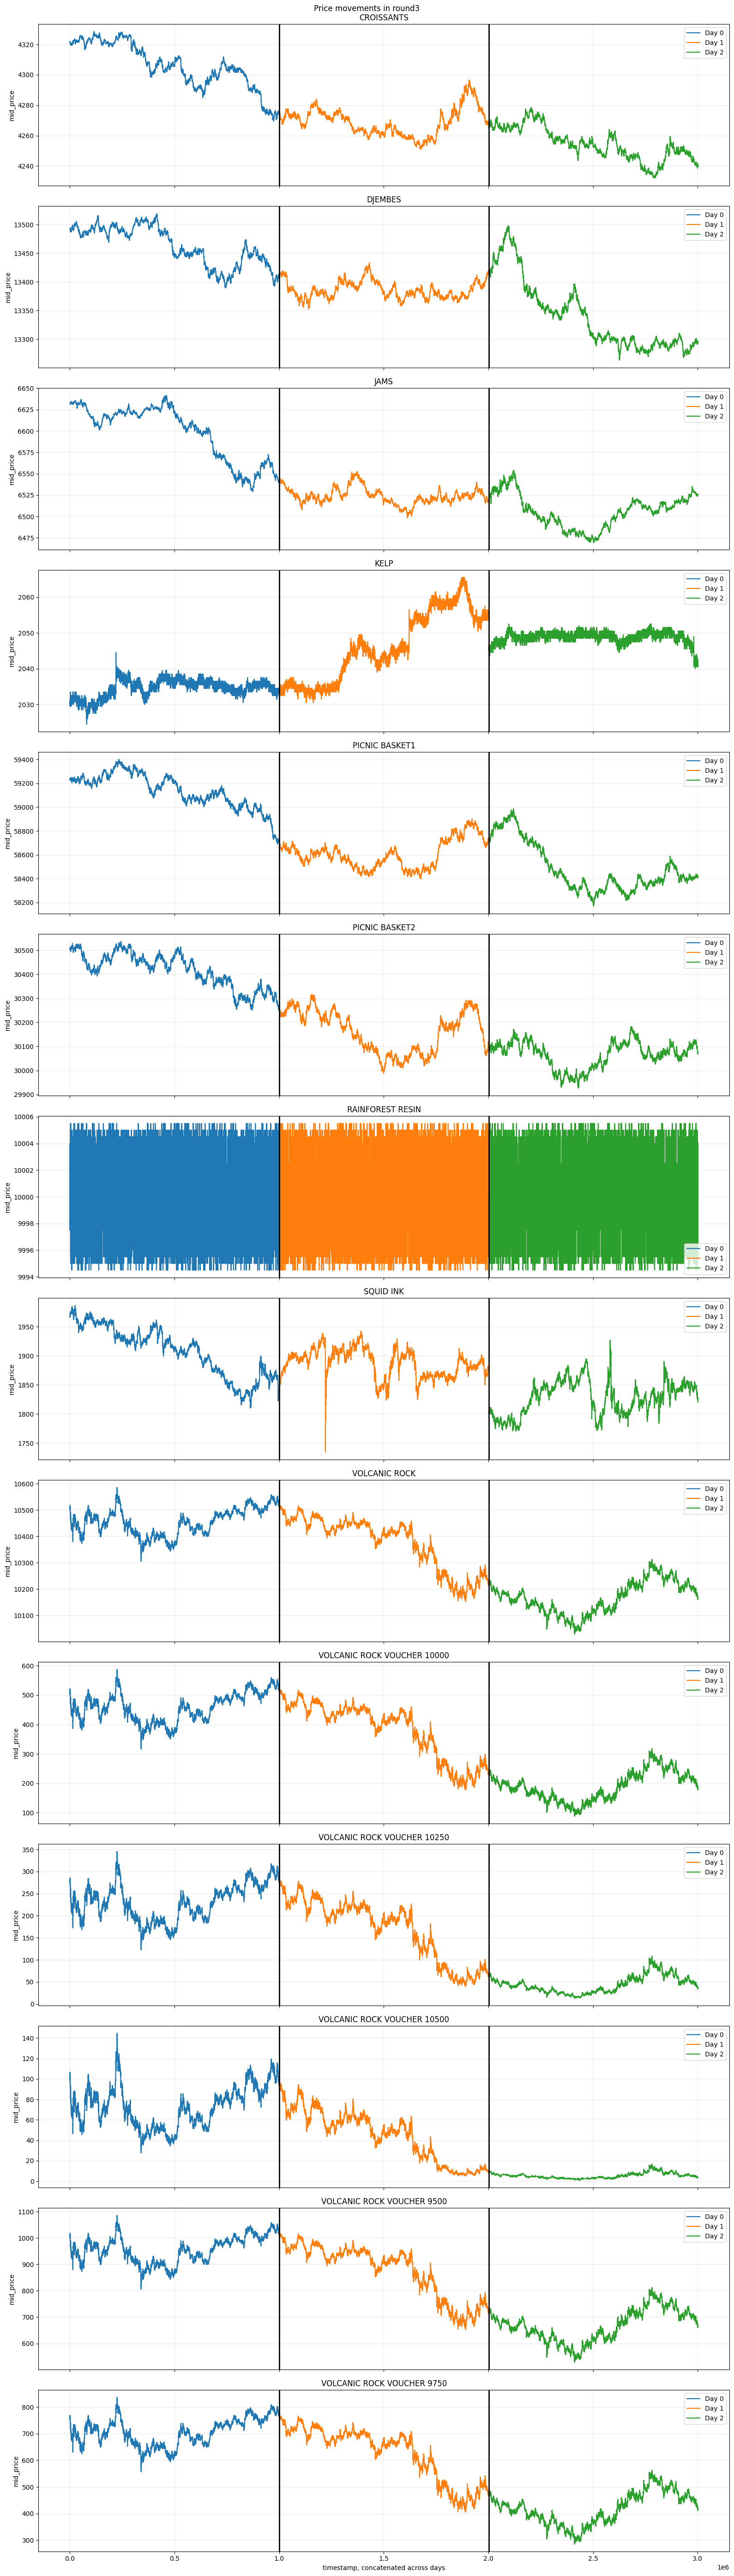

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 3
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
ROUND_FOLDER = next((folder for folder in candidate_folders if folder.exists()), None)
if ROUND_FOLDER is None:
    raise FileNotFoundError(f"Could not find the round{ROUND_NUMBER} folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
products = sorted(prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = prices[prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = prices[prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


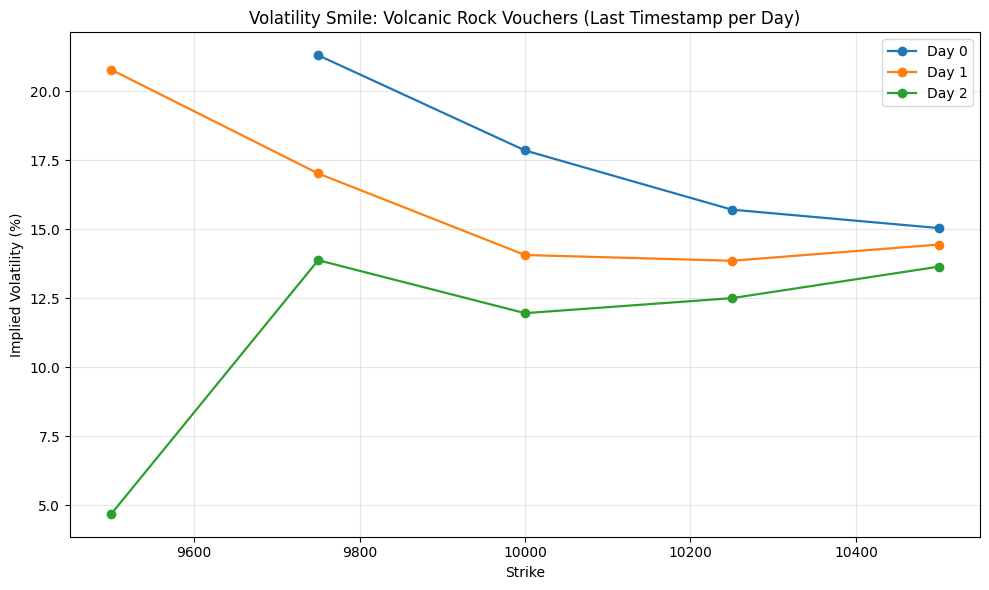

In [2]:
from pathlib import Path
import re
from math import erf, exp, log, sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROUND_NUMBER = 3
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
round_folder = next((folder for folder in candidate_folders if folder.exists()), None)
if round_folder is None:
    raise FileNotFoundError(
        f"Could not find round{ROUND_NUMBER} data folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}"
    )

price_files = sorted(round_folder.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not price_files:
    raise FileNotFoundError(f"No files matching prices_round_{ROUND_NUMBER}_day_x.csv in {round_folder}")

frames = []
day_re = re.compile(r"day_(-?\d+)\.csv$")
for file_path in price_files:
    match = day_re.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

prices = pd.concat(frames, ignore_index=True)
prices["timestamp"] = pd.to_numeric(prices["timestamp"], errors="coerce")
prices["mid_price"] = pd.to_numeric(prices["mid_price"], errors="coerce")
prices = prices.dropna(subset=["timestamp", "mid_price"])

voucher_re = re.compile(r"^VOLCANIC_ROCK_VOUCHER_(\d+)$")
vouchers = prices[prices["product"].str.startswith("VOLCANIC_ROCK_VOUCHER_")].copy()
vouchers["strike"] = vouchers["product"].str.extract(voucher_re)[0].astype(float)
underlying = prices[prices["product"] == "VOLCANIC_ROCK"].copy()

merged = vouchers.merge(
    underlying[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "spot"}),
    on=["day", "timestamp"],
    how="inner",
)
merged = merged.rename(columns={"mid_price": "option_price"})


def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def bs_call_price(spot: float, strike: float, ttm: float, sigma: float, rate: float = 0.0) -> float:
    if sigma <= 0 or ttm <= 0:
        return max(spot - strike, 0.0)
    d1 = (log(spot / strike) + (rate + 0.5 * sigma * sigma) * ttm) / (sigma * sqrt(ttm))
    d2 = d1 - sigma * sqrt(ttm)
    return spot * norm_cdf(d1) - strike * exp(-rate * ttm) * norm_cdf(d2)


def implied_vol_call(
    price: float,
    spot: float,
    strike: float,
    ttm: float,
    rate: float = 0.0,
    sigma_low: float = 1e-4,
    sigma_high: float = 3.0,
    tol: float = 1e-6,
    max_iter: int = 100,
):
    intrinsic = max(spot - strike * exp(-rate * ttm), 0.0)
    upper_bound = spot
    if not (intrinsic <= price <= upper_bound):
        return np.nan

    low = sigma_low
    high = sigma_high
    f_low = bs_call_price(spot, strike, ttm, low, rate) - price
    f_high = bs_call_price(spot, strike, ttm, high, rate) - price

    if f_low * f_high > 0:
        return np.nan

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = bs_call_price(spot, strike, ttm, mid, rate) - price
        if abs(f_mid) < tol:
            return mid
        if f_low * f_mid <= 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5 * (low + high)


TTM_YEARS = 7 / 365  # adjust if you have a better estimate for time-to-expiry
RISK_FREE_RATE = 0.0

merged["implied_vol"] = merged.apply(
    lambda row: implied_vol_call(
        price=float(row["option_price"]),
        spot=float(row["spot"]),
        strike=float(row["strike"]),
        ttm=TTM_YEARS,
        rate=RISK_FREE_RATE,
    ),
    axis=1,
)

smile_points = []
for day, day_df in merged.groupby("day"):
    t_last = day_df["timestamp"].max()
    snap = day_df[day_df["timestamp"] == t_last].copy()
    snap = snap.dropna(subset=["implied_vol"]).sort_values("strike")
    if not snap.empty:
        snap["day"] = day
        smile_points.append(snap)

if not smile_points:
    raise ValueError("No valid implied volatility points found. Check option price bounds and TTM assumption.")

smile = pd.concat(smile_points, ignore_index=True)

plt.figure(figsize=(10, 6))
for day in sorted(smile["day"].unique()):
    day_smile = smile[smile["day"] == day]
    plt.plot(day_smile["strike"], 100 * day_smile["implied_vol"], marker="o", linewidth=1.6, label=f"Day {day}")

plt.title("Volatility Smile: Volcanic Rock Vouchers (Last Timestamp per Day)")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

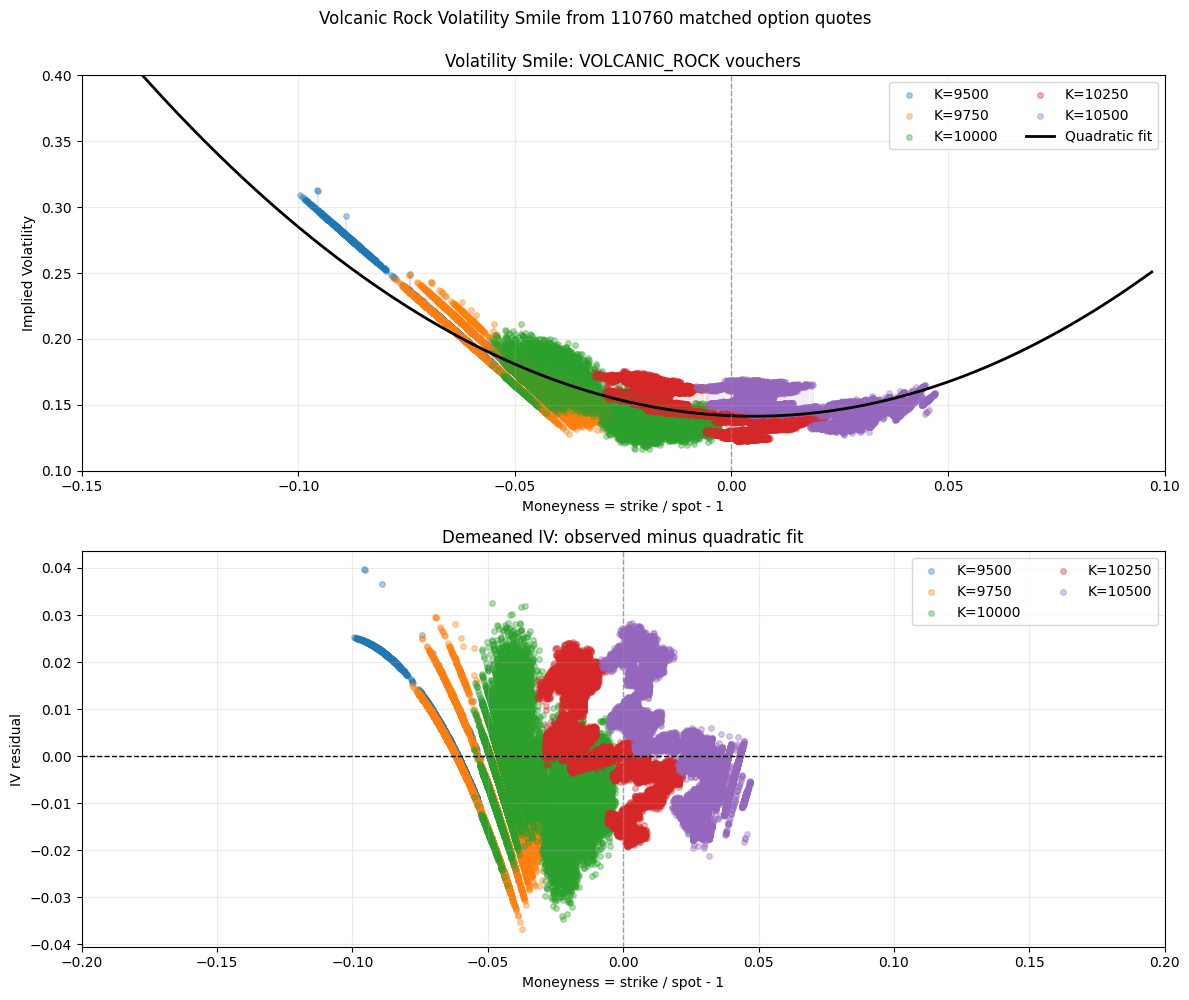

,day,timestamp,product,strike,spot,option_price,moneyness,implied_vol,iv_residual
0,0,973100,VOLCANIC_ROCK_VOUCHER_9500,9500.0,10550.5,1051.5,-0.099569,0.309064,0.025254
1,0,863400,VOLCANIC_ROCK_VOUCHER_9500,9500.0,10545.5,1046.5,-0.099142,0.307840,0.025189
2,0,976600,VOLCANIC_ROCK_VOUCHER_9500,9500.0,10540.5,1041.5,-0.098714,0.306615,0.025119
3,0,864200,VOLCANIC_ROCK_VOUCHER_9500,9500.0,10536.5,1037.5,-0.098372,0.305634,0.025059
4,0,994900,VOLCANIC_ROCK_VOUCHER_9500,9500.0,10536.0,1037.0,-0.098330,0.305511,0.025052
...,...,...,...,...,...,...,...,...,...
110755,2,409200,VOLCANIC_ROCK_VOUCHER_10500,10500.0,10030.0,1.5,0.046859,0.158299,-0.005586
110756,2,409400,VOLCANIC_ROCK_VOUCHER_10500,10500.0,10030.0,1.5,0.046859,0.158299,-0.005586
110757,2,409300,VOLCANIC_ROCK_VOUCHER_10500,10500.0,10029.5,1.5,0.046912,0.158446,-0.005495
110758,2,410500,VOLCANIC_ROCK_VOUCHER_10500,10500.0,10029.0,1.5,0.046964,0.158594,-0.005404


In [12]:
from pathlib import Path
import re
from math import erf, exp, log, sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROUND_NUMBER = 3
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
round_folder = next((folder for folder in candidate_folders if folder.exists()), None)
if round_folder is None:
    raise FileNotFoundError(
        f"Could not find round{ROUND_NUMBER} data folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}"
    )

price_files = sorted(round_folder.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not price_files:
    raise FileNotFoundError(f"No files matching prices_round_{ROUND_NUMBER}_day_*.csv in {round_folder}")

frames = []
day_re = re.compile(r"day_(-?\d+)\.csv$")
for file_path in price_files:
    match = day_re.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

prices = pd.concat(frames, ignore_index=True)
prices = prices.dropna(subset=["timestamp", "mid_price"])
prices["product"] = prices["product"].astype(str).str.strip().str.upper()

voucher_re = re.compile(r"^VOLCANIC_ROCK_VOUCHER_(\d+)$")
vouchers = prices[prices["product"].str.startswith("VOLCANIC_ROCK_VOUCHER_")].copy()
vouchers["strike"] = vouchers["product"].str.extract(voucher_re)[0].astype(float)
underlying = prices[prices["product"] == "VOLCANIC_ROCK"].copy()

merged = vouchers.merge(
    underlying[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "spot"}),
    on=["day", "timestamp"],
    how="inner",
)
merged = merged.rename(columns={"mid_price": "option_price"})
merged = merged.dropna(subset=["spot", "option_price", "strike"])


def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def bs_call_price(spot: float, strike: float, ttm: float, sigma: float, rate: float = 0.0) -> float:
    if sigma <= 0 or ttm <= 0:
        return max(spot - strike, 0.0)
    d1 = (log(spot / strike) + (rate + 0.5 * sigma * sigma) * ttm) / (sigma * sqrt(ttm))
    d2 = d1 - sigma * sqrt(ttm)
    return spot * norm_cdf(d1) - strike * exp(-rate * ttm) * norm_cdf(d2)


def implied_vol_call(
    price: float,
    spot: float,
    strike: float,
    ttm: float,
    rate: float = 0.0,
    sigma_low: float = 1e-4,
    sigma_high: float = 3.0,
    tol: float = 1e-6,
    max_iter: int = 100,
):
    intrinsic = max(spot - strike * exp(-rate * ttm), 0.0)
    upper_bound = spot
    if not (intrinsic <= price <= upper_bound):
        return np.nan

    low = sigma_low
    high = sigma_high
    f_low = bs_call_price(spot, strike, ttm, low, rate) - price
    f_high = bs_call_price(spot, strike, ttm, high, rate) - price

    if f_low * f_high > 0:
        return np.nan

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = bs_call_price(spot, strike, ttm, mid, rate) - price
        if abs(f_mid) < tol:
            return mid
        if f_low * f_mid <= 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5 * (low + high)


TTM_YEARS = 7 / 365  # adjust if you have a better estimate for time-to-expiry
RISK_FREE_RATE = 0.0

merged["implied_vol"] = merged.apply(
    lambda row: implied_vol_call(
        price=float(row["option_price"]),
        spot=float(row["spot"]),
        strike=float(row["strike"]),
        ttm=TTM_YEARS,
        rate=RISK_FREE_RATE,
    ),
    axis=1,
)

# Use the full cloud of matched quotes rather than just the last timestamp of each day.
smile = merged.dropna(subset=["implied_vol", "spot", "strike"]).copy()
smile["moneyness"] = smile["strike"] / smile["spot"] - 1.0
smile["intrinsic"] = np.maximum(smile["spot"] - smile["strike"], 0.0)
smile["extrinsic"] = smile["option_price"] - smile["intrinsic"]

# Filter the unstable bottom-left outliers where option value is too close to intrinsic.
smile = smile[
    smile["implied_vol"].between(0.05, 0.8)
    & smile["moneyness"].between(-0.9, 0.9)
    & (smile["extrinsic"] > 0.5)
].copy()

if len(smile) < 5:
    raise ValueError("Not enough clean points to plot the volatility smile.")

smile = smile.sort_values(["strike", "moneyness", "timestamp"]).reset_index(drop=True)
fit_coeffs = np.polyfit(smile["moneyness"], smile["implied_vol"], deg=2)
fit_curve = np.poly1d(fit_coeffs)
smile["iv_fair"] = fit_curve(smile["moneyness"])
smile["iv_residual"] = smile["implied_vol"] - smile["iv_fair"]

x_grid = np.linspace(smile["moneyness"].min() - 0.05, smile["moneyness"].max() + 0.05, 400)
y_grid = fit_curve(x_grid)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharey=False)
colors = plt.get_cmap("tab10")
strikes = sorted(smile["strike"].dropna().unique())

for idx, strike in enumerate(strikes):
    strike_df = smile[smile["strike"] == strike].sort_values("moneyness")
    color = colors(idx % colors.N)

    axes[0].scatter(
        strike_df["moneyness"],
        strike_df["implied_vol"],
        s=16,
        alpha=0.35,
        color=color,
        label=f"K={int(strike)}",
    )
    axes[0].plot(
        strike_df["moneyness"],
        strike_df["implied_vol"],
        color=color,
        alpha=0.12,
        linewidth=0.8,
    )

    axes[1].scatter(
        strike_df["moneyness"],
        strike_df["iv_residual"],
        s=16,
        alpha=0.35,
        color=color,
        label=f"K={int(strike)}",
    )

axes[0].plot(x_grid, y_grid, color="black", linewidth=2.0, label="Quadratic fit")
axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
axes[0].set_title("Volatility Smile: VOLCANIC_ROCK vouchers")
axes[0].set_xlabel("Moneyness = strike / spot - 1")
axes[0].set_ylabel("Implied Volatility")
axes[0].set_xlim(-0.15, 0.1)
axes[0].set_ylim(0.1, 0.4)
axes[0].grid(alpha=0.25)
axes[0].legend(loc="best", ncol=2)

axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
axes[1].set_title("Demeaned IV: observed minus quadratic fit")
axes[1].set_xlabel("Moneyness = strike / spot - 1")
axes[1].set_ylabel("IV residual")
axes[1].set_xlim(-0.2, 0.2)
axes[1].grid(alpha=0.25)
axes[1].legend(loc="best", ncol=2)

fig.suptitle(
    f"Volcanic Rock Volatility Smile from {len(smile)} matched option quotes",
    y=0.995,
)
fig.tight_layout()
plt.show()

smile[["day", "timestamp", "product", "strike", "spot", "option_price", "moneyness", "implied_vol", "iv_residual"]]

Analysis: these are normally distributed. You can do marketmaking pretty sure. there may be drift? not as clear as the simple day 1 ones

Not sure why there are gaps, hoping thats just the buckets not properly filling

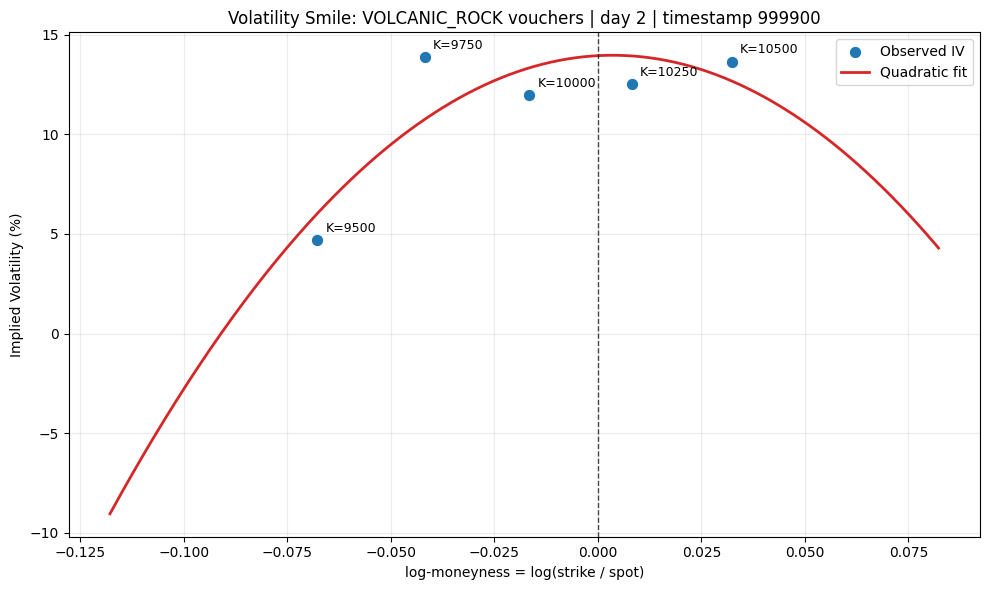

,day,timestamp,product,strike,spot,option_price,log_moneyness,implied_vol
149999,2,999900,VOLCANIC_ROCK_VOUCHER_9500,9500.0,10166.5,666.5,-0.067806,0.046973
149998,2,999900,VOLCANIC_ROCK_VOUCHER_9750,9750.0,10166.5,417.5,-0.041831,0.138792
149997,2,999900,VOLCANIC_ROCK_VOUCHER_10000,10000.0,10166.5,180.5,-0.016513,0.119619
149996,2,999900,VOLCANIC_ROCK_VOUCHER_10250,10250.0,10166.5,36.5,0.008180,0.125053
149995,2,999900,VOLCANIC_ROCK_VOUCHER_10500,10500.0,10166.5,3.5,0.032277,0.136449


In [4]:
from pathlib import Path
import re
from math import erf, exp, log, sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROUND_NUMBER = 3
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
round_folder = next((folder for folder in candidate_folders if folder.exists()), None)
if round_folder is None:
    raise FileNotFoundError(
        f"Could not find round{ROUND_NUMBER} data folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}"
    )

price_files = sorted(round_folder.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not price_files:
    raise FileNotFoundError(f"No files matching prices_round_{ROUND_NUMBER}_day_*.csv in {round_folder}")

frames = []
day_re = re.compile(r"day_(-?\d+)\.csv$")
for file_path in price_files:
    match = day_re.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

prices = pd.concat(frames, ignore_index=True)
prices = prices.dropna(subset=["timestamp", "mid_price"])
prices["product"] = prices["product"].astype(str).str.strip().str.upper()

voucher_re = re.compile(r"^VOLCANIC_ROCK_VOUCHER_(\d+)$")
vouchers = prices[prices["product"].str.startswith("VOLCANIC_ROCK_VOUCHER_")].copy()
vouchers["strike"] = vouchers["product"].str.extract(voucher_re)[0].astype(float)
underlying = prices[prices["product"] == "VOLCANIC_ROCK"].copy()

merged = vouchers.merge(
    underlying[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "spot"}),
    on=["day", "timestamp"],
    how="inner",
)
merged = merged.rename(columns={"mid_price": "option_price"})
merged = merged.dropna(subset=["spot", "option_price", "strike"])


def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def bs_call_price(spot: float, strike: float, ttm: float, sigma: float, rate: float = 0.0) -> float:
    if sigma <= 0 or ttm <= 0:
        return max(spot - strike, 0.0)
    d1 = (log(spot / strike) + (rate + 0.5 * sigma * sigma) * ttm) / (sigma * sqrt(ttm))
    d2 = d1 - sigma * sqrt(ttm)
    return spot * norm_cdf(d1) - strike * exp(-rate * ttm) * norm_cdf(d2)


def implied_vol_call(
    price: float,
    spot: float,
    strike: float,
    ttm: float,
    rate: float = 0.0,
    sigma_low: float = 1e-4,
    sigma_high: float = 3.0,
    tol: float = 1e-6,
    max_iter: int = 100,
):
    intrinsic = max(spot - strike * exp(-rate * ttm), 0.0)
    upper_bound = spot
    if not (intrinsic <= price <= upper_bound):
        return np.nan

    low = sigma_low
    high = sigma_high
    f_low = bs_call_price(spot, strike, ttm, low, rate) - price
    f_high = bs_call_price(spot, strike, ttm, high, rate) - price

    if f_low * f_high > 0:
        return np.nan

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = bs_call_price(spot, strike, ttm, mid, rate) - price
        if abs(f_mid) < tol:
            return mid
        if f_low * f_mid <= 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5 * (low + high)


TTM_YEARS = 7 / 365  # adjust if you have a better estimate for time-to-expiry
RISK_FREE_RATE = 0.0

merged["implied_vol"] = merged.apply(
    lambda row: implied_vol_call(
        price=float(row["option_price"]),
        spot=float(row["spot"]),
        strike=float(row["strike"]),
        ttm=TTM_YEARS,
        rate=RISK_FREE_RATE,
    ),
    axis=1,
)

latest_day = int(merged["day"].max())
day_data = merged[merged["day"] == latest_day].copy()
latest_timestamp = day_data["timestamp"].max()
snapshot = day_data[day_data["timestamp"] == latest_timestamp].copy()
snapshot = snapshot.dropna(subset=["implied_vol"]).sort_values("strike")
snapshot = snapshot.drop_duplicates(subset=["strike"], keep="last")

if len(snapshot) < 3:
    raise ValueError("Need at least 3 valid option points to fit a smile curve.")

snapshot["log_moneyness"] = np.log(snapshot["strike"] / snapshot["spot"])

fit_coeffs = np.polyfit(snapshot["log_moneyness"], snapshot["implied_vol"], deg=2)
fit_curve = np.poly1d(fit_coeffs)

x_grid = np.linspace(snapshot["log_moneyness"].min() - 0.05, snapshot["log_moneyness"].max() + 0.05, 300)
y_grid = fit_curve(x_grid)

plt.figure(figsize=(10, 6))
plt.scatter(
    snapshot["log_moneyness"],
    100 * snapshot["implied_vol"],
    s=80,
    color="tab:blue",
    edgecolor="white",
    linewidth=0.8,
    label="Observed IV",
)
plt.plot(x_grid, 100 * y_grid, color="tab:red", linewidth=2.0, label="Quadratic fit")

for _, row in snapshot.iterrows():
    plt.annotate(
        f"K={int(row['strike'])}",
        (row["log_moneyness"], 100 * row["implied_vol"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

plt.axvline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.title(f"Volatility Smile: VOLCANIC_ROCK vouchers | day {latest_day} | timestamp {int(latest_timestamp)}")
plt.xlabel("log-moneyness = log(strike / spot)")
plt.ylabel("Implied Volatility (%)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

snapshot[["day", "timestamp", "product", "strike", "spot", "option_price", "log_moneyness", "implied_vol"]]

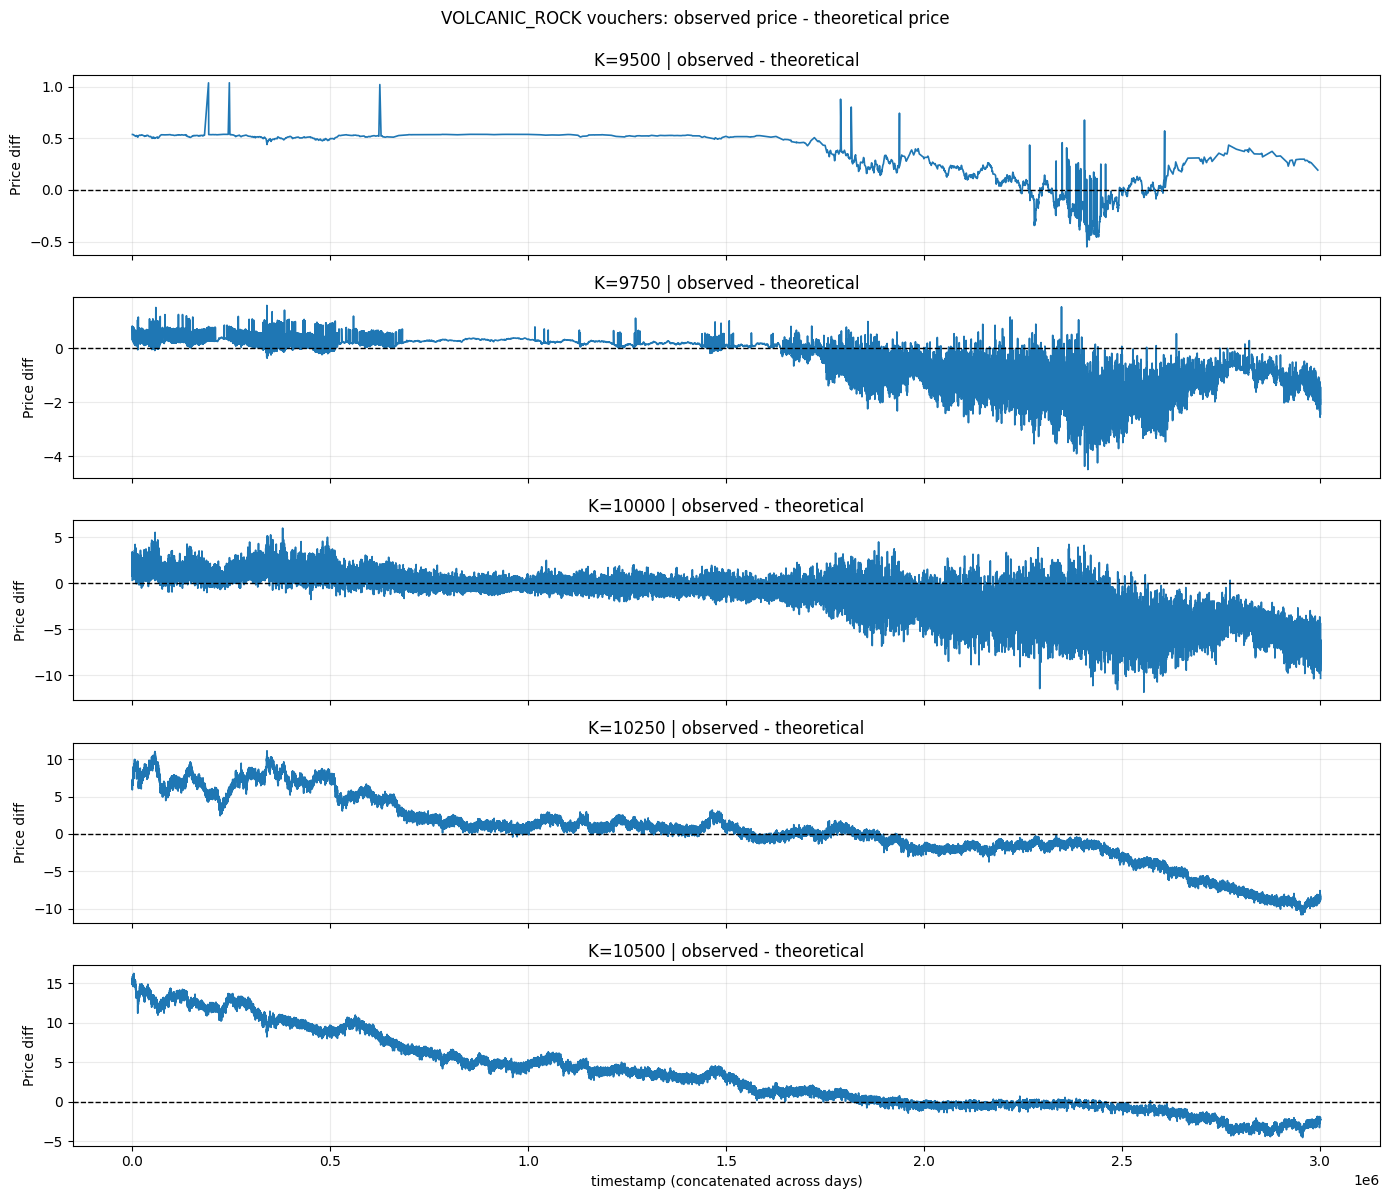

,day,timestamp,strike,option_price,price_theoretical,price_diff
0,0,973100,9500.0,1051.5,1050.962116,0.537884
1,0,863400,9500.0,1046.5,1045.961868,0.538132
2,0,976600,9500.0,1041.5,1040.961694,0.538306
3,0,864200,9500.0,1037.5,1036.961607,0.538393
4,0,994900,9500.0,1037.0,1036.461599,0.538401
...,...,...,...,...,...,...
110755,2,409200,10500.0,1.5,1.885196,-0.385196
110756,2,409400,10500.0,1.5,1.885196,-0.385196
110757,2,409300,10500.0,1.5,1.878190,-0.378190
110758,2,410500,10500.0,1.5,1.871216,-0.371216


In [13]:
# Price mispricing over time: observed option price - theoretical option price
# Requires the previous smile cell to have created: smile, fit_curve, bs_call_price, TTM_YEARS, RISK_FREE_RATE.
required_names = ["smile", "fit_curve", "bs_call_price", "TTM_YEARS", "RISK_FREE_RATE"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Run the smile-fitting cell first. Missing variables/functions: {missing}")

mis = smile[["day", "timestamp", "strike", "spot", "option_price", "moneyness"]].copy()
mis["iv_theoretical"] = fit_curve(mis["moneyness"])
mis["iv_theoretical"] = np.clip(mis["iv_theoretical"], 1e-4, None)

mis["price_theoretical"] = mis.apply(
    lambda row: bs_call_price(
        spot=float(row["spot"]),
        strike=float(row["strike"]),
        ttm=float(TTM_YEARS),
        sigma=float(row["iv_theoretical"]),
        rate=float(RISK_FREE_RATE),
    ),
    axis=1,
)
mis["price_diff"] = mis["option_price"] - mis["price_theoretical"]

# Build a continuous time axis across days to keep ordering clear.
days_sorted = sorted(mis["day"].dropna().unique())
gap = 1000.0
x_offsets = {}
current_offset = 0.0
for d in days_sorted:
    day_max_t = float(mis.loc[mis["day"] == d, "timestamp"].max())
    x_offsets[d] = current_offset
    current_offset += day_max_t + gap

mis["x_time"] = mis["timestamp"] + mis["day"].map(x_offsets)

strikes = sorted(mis["strike"].dropna().unique())
if len(strikes) > 5:
    strikes = strikes[:5]

fig, axes = plt.subplots(len(strikes), 1, figsize=(14, 2.4 * len(strikes)), sharex=True)
if len(strikes) == 1:
    axes = [axes]

for ax, strike in zip(axes, strikes):
    s = mis[mis["strike"] == strike].sort_values(["day", "timestamp"])
    ax.plot(s["x_time"], s["price_diff"], linewidth=1.2, color="tab:blue")
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"K={int(strike)} | observed - theoretical")
    ax.set_ylabel("Price diff")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("timestamp (concatenated across days)")
fig.suptitle("VOLCANIC_ROCK vouchers: observed price - theoretical price", y=0.995)
fig.tight_layout()
plt.show()

mis[["day", "timestamp", "strike", "option_price", "price_theoretical", "price_diff"]]

These all trend downwards I think its poorly fit

Fitted coefficients (plug into bot): [0.23728958, 0.00293511, 0.14919635]


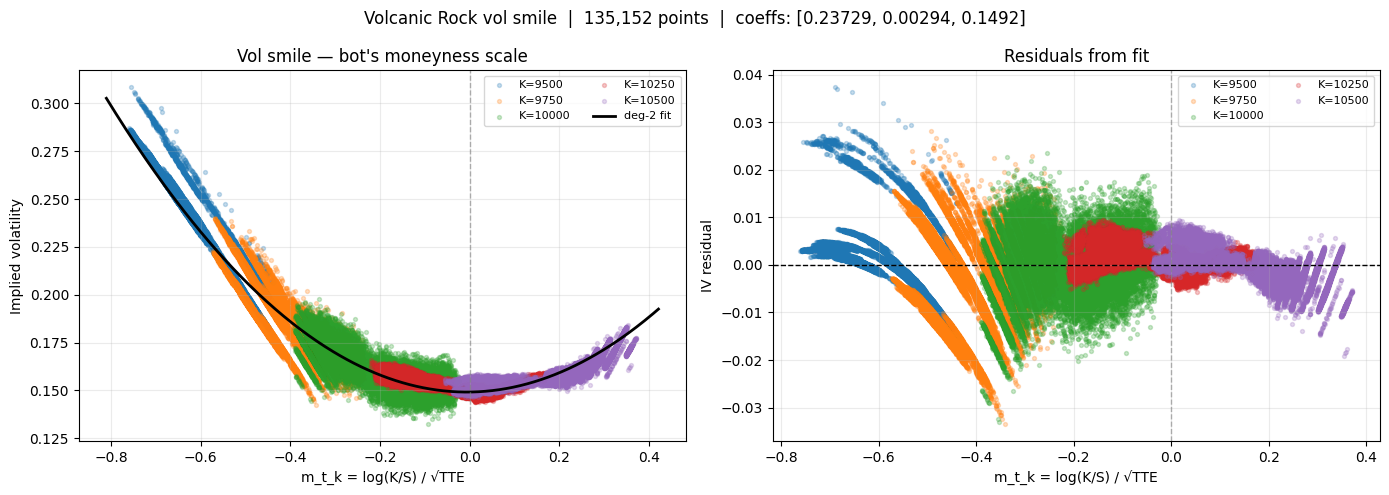

In [6]:
# Vol smile using the bot's moneyness: m_t_k = log(K/S) / sqrt(TTE)
# TTE decays linearly: 8 days at (day=0, ts=0) down to 5 days at (day=2, ts=999900)

import re
from math import erf, exp, log, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DAYS_PER_YEAR  = 365
RISK_FREE_RATE = 0.0

# ── reload data if needed ────────────────────────────────────────────────────
if "merged" not in dir():
    ROUND_NUMBER = 3
    candidate_folders = [Path(f"round{ROUND_NUMBER}"), Path("2025") / f"round{ROUND_NUMBER}"]
    round_folder = next((f for f in candidate_folders if f.exists()), None)
    if round_folder is None:
        raise FileNotFoundError("Could not find round3 data folder.")

    frames, day_re = [], re.compile(r"day_(-?\d+)\.csv$")
    for fp in sorted(round_folder.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv")):
        m = day_re.search(fp.name)
        if not m:
            continue
        day = int(m.group(1))
        df = pd.read_csv(fp, sep=";")
        df["day"] = day
        df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
        df["mid_price"]  = pd.to_numeric(df["mid_price"],  errors="coerce")
        frames.append(df[["day", "timestamp", "product", "mid_price"]])

    prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
    prices["product"] = prices["product"].astype(str).str.strip().str.upper()

    voucher_re = re.compile(r"^VOLCANIC_ROCK_VOUCHER_(\d+)$")
    vouchers   = prices[prices["product"].str.startswith("VOLCANIC_ROCK_VOUCHER_")].copy()
    vouchers["strike"] = vouchers["product"].str.extract(voucher_re)[0].astype(float)
    underlying = prices[prices["product"] == "VOLCANIC_ROCK"].copy()

    merged = vouchers.merge(
        underlying[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "spot"}),
        on=["day", "timestamp"], how="inner",
    ).rename(columns={"mid_price": "option_price"}).dropna(subset=["spot", "option_price", "strike"])

# ── per-row TTE: 8 days at (day=0, ts=0), 5 days at (day=2, ts=999900) ──────
merged["tte"] = (8 - merged["day"] - merged["timestamp"] / 1_000_000) / DAYS_PER_YEAR
merged = merged[merged["tte"] > 0].copy()

# ── back-solve IV with per-row TTE ───────────────────────────────────────────
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_call(S, K, tte, sigma, r=0.0):
    if sigma <= 0 or tte <= 0:
        return max(S - K, 0.0)
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * tte) / (sigma * sqrt(tte))
    d2 = d1 - sigma * sqrt(tte)
    return S * norm_cdf(d1) - K * exp(-r * tte) * norm_cdf(d2)

def implied_vol(price, S, K, tte, r=0.0):
    intrinsic = max(S - K * exp(-r * tte), 0.0)
    if not (intrinsic <= price <= S):
        return np.nan
    lo, hi = 1e-4, 3.0
    fl = bs_call(S, K, tte, lo, r) - price
    fh = bs_call(S, K, tte, hi, r) - price
    if fl * fh > 0:
        return np.nan
    for _ in range(100):
        mid = 0.5 * (lo + hi)
        fm  = bs_call(S, K, tte, mid, r) - price
        if abs(fm) < 1e-6:
            return mid
        if fl * fm <= 0:
            hi, fh = mid, fm
        else:
            lo, fl = mid, fm
    return 0.5 * (lo + hi)

merged["iv"] = merged.apply(
    lambda r: implied_vol(float(r["option_price"]), float(r["spot"]),
                          float(r["strike"]), float(r["tte"]), RISK_FREE_RATE),
    axis=1,
)

# ── m_t_k = log(K/S) / sqrt(TTE) ────────────────────────────────────────────
merged["m_t_k"] = np.log(merged["strike"] / merged["spot"]) / np.sqrt(merged["tte"])

smile = merged.dropna(subset=["iv", "m_t_k"]).copy()
smile = smile[smile["iv"].between(0.1, 1.5)].copy()

# ── polynomial fit ───────────────────────────────────────────────────────────
coeffs = np.polyfit(smile["m_t_k"], smile["iv"], deg=2)
poly   = np.poly1d(coeffs)
x_grid = np.linspace(smile["m_t_k"].min() - 0.05, smile["m_t_k"].max() + 0.05, 400)
y_grid = poly(x_grid)

print(f"Fitted coefficients (plug into bot): {np.round(coeffs, 8).tolist()}")

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap    = plt.get_cmap("tab10")
strikes = sorted(smile["strike"].unique())

for i, k in enumerate(strikes):
    sub = smile[smile["strike"] == k]
    axes[0].scatter(sub["m_t_k"], sub["iv"], s=8, alpha=0.25, color=cmap(i), label=f"K={int(k)}")

axes[0].plot(x_grid, y_grid, color="black", lw=2, label="deg-2 fit")
axes[0].axvline(0, color="gray", ls="--", lw=1, alpha=0.6)
axes[0].set_xlabel("m_t_k = log(K/S) / √TTE")
axes[0].set_ylabel("Implied volatility")
axes[0].set_title("Vol smile — bot's moneyness scale")
axes[0].legend(ncol=2, fontsize=8)
axes[0].grid(alpha=0.25)

smile["iv_fit"]      = poly(smile["m_t_k"])
smile["iv_residual"] = smile["iv"] - smile["iv_fit"]
for i, k in enumerate(strikes):
    sub = smile[smile["strike"] == k]
    axes[1].scatter(sub["m_t_k"], sub["iv_residual"], s=8, alpha=0.25, color=cmap(i), label=f"K={int(k)}")

axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].axvline(0, color="gray",  ls="--", lw=1, alpha=0.6)
axes[1].set_xlabel("m_t_k = log(K/S) / √TTE")
axes[1].set_ylabel("IV residual")
axes[1].set_title("Residuals from fit")
axes[1].legend(ncol=2, fontsize=8)
axes[1].grid(alpha=0.25)

fig.suptitle(f"Volcanic Rock vol smile  |  {len(smile):,} points  |  coeffs: {np.round(coeffs, 5).tolist()}")
fig.tight_layout()
plt.show()


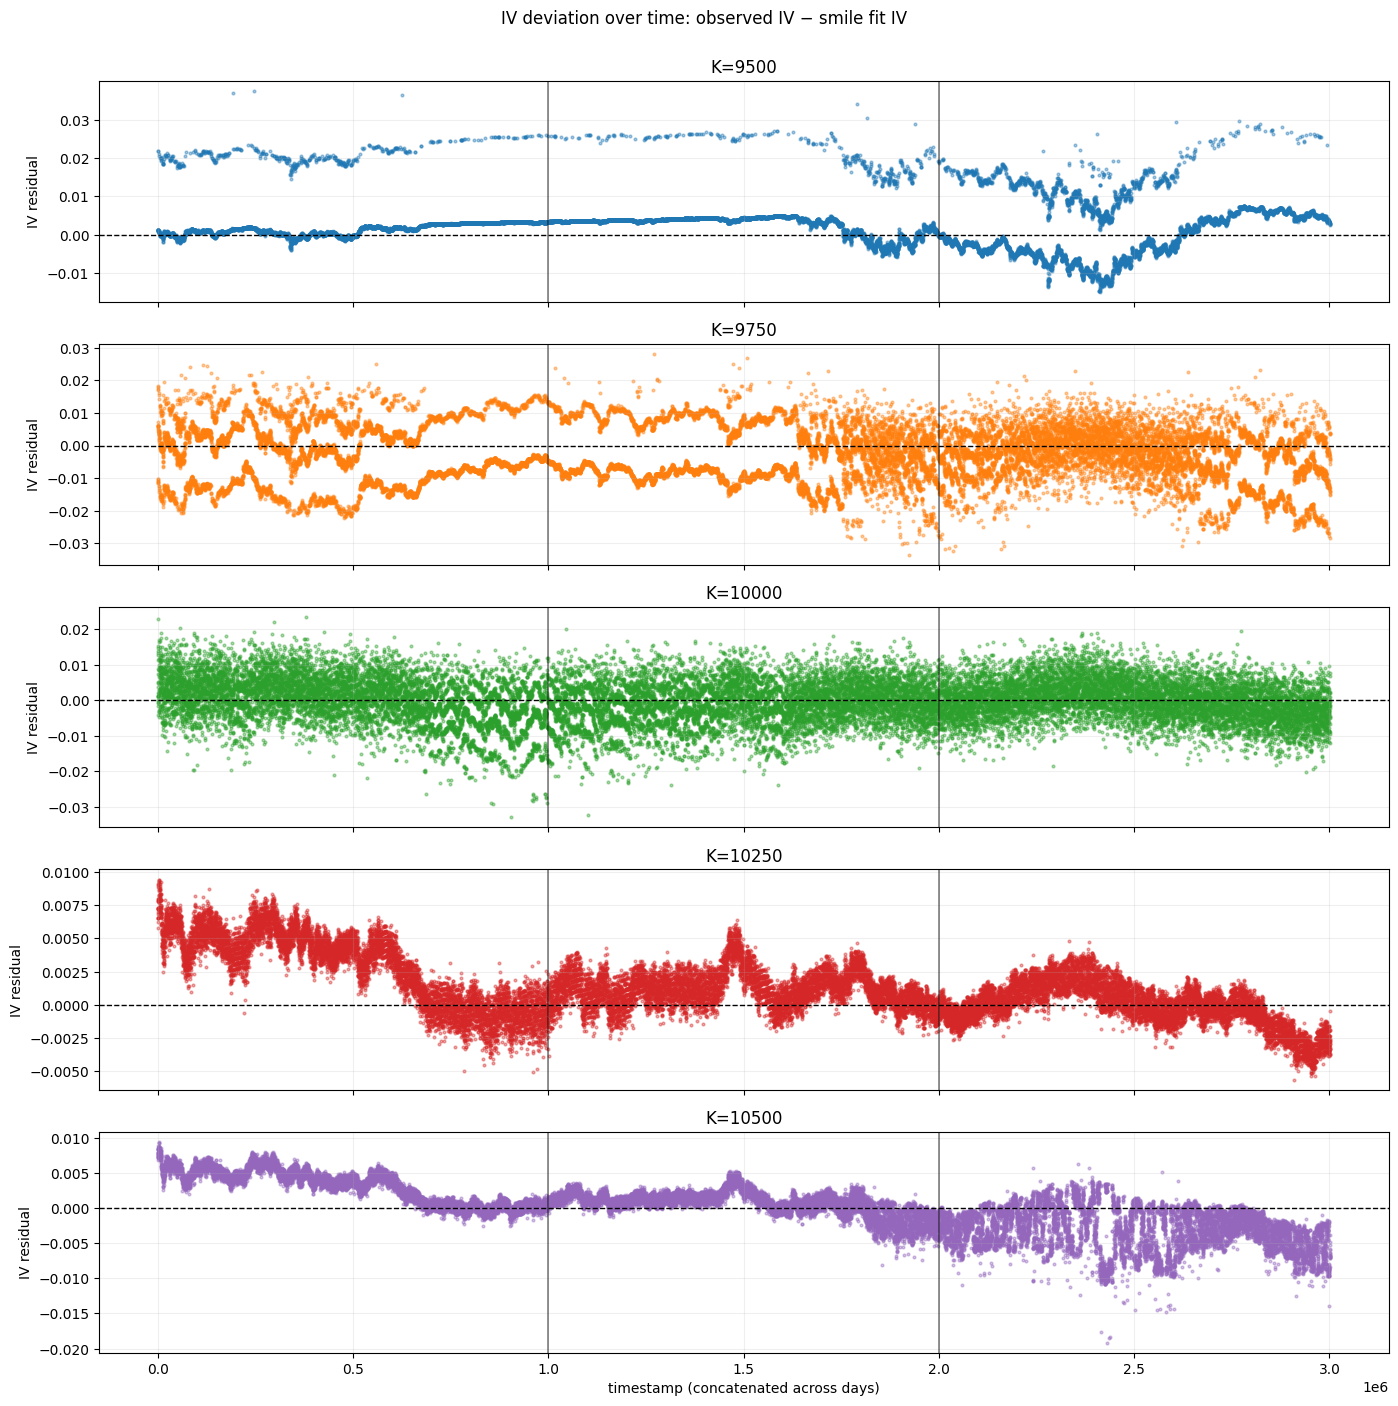

In [7]:
# IV deviation over time per strike: observed IV - smile fit IV
# Requires the cell above to have run (produces `smile` with iv_residual column)

if "smile" not in dir() or "iv_residual" not in smile.columns:
    raise RuntimeError("Run the vol smile cell above first.")

days_sorted = sorted(smile["day"].unique())
gap = 1000.0
x_offsets, current_offset = {}, 0.0
for d in days_sorted:
    max_ts = float(smile.loc[smile["day"] == d, "timestamp"].max())
    x_offsets[d] = current_offset
    current_offset += max_ts + gap

smile["x_time"] = smile["timestamp"] + smile["day"].map(x_offsets)

strikes = sorted(smile["strike"].unique())
fig, axes = plt.subplots(len(strikes), 1, figsize=(14, 2.8 * len(strikes)), sharex=True)
if len(strikes) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
for ax, (i, k) in zip(axes, enumerate(strikes)):
    sub = smile[smile["strike"] == k].sort_values(["day", "timestamp"])
    ax.scatter(sub["x_time"], sub["iv_residual"], s=4, alpha=0.4, color=cmap(i))
    ax.axhline(0, color="black", lw=1, ls="--")
    for d in days_sorted[:-1]:
        sep = x_offsets[d] + float(smile.loc[smile["day"] == d, "timestamp"].max()) + gap / 2
        ax.axvline(sep, color="black", lw=1.2, alpha=0.5)
    ax.set_ylabel("IV residual")
    ax.set_title(f"K={int(k)}")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("timestamp (concatenated across days)")
fig.suptitle("IV deviation over time: observed IV − smile fit IV", y=1.001)
fig.tight_layout()
plt.show()
